In [ ]:
import os

dataset_path = "/kaggle/input/datasets/mbornoe/lisa-traffic-light-dataset"
items = os.listdir(dataset_path)
len(items)

9

In [3]:
for item in items:
    path = os.path.join(dataset_path, item)
    if os.path.isdir(path):
        print(f"\n {item}")
        print(os.listdir(path)[:20])


 nightTrain
['nightTrain']

 nightSequence1
['nightSequence1']

 daySequence1
['daySequence1']

 Annotations
['Annotations']

 sample-nightClip1
['sample-nightClip1']

 sample-dayClip6
['sample-dayClip6']

 daySequence2
['daySequence2']

 nightSequence2
['nightSequence2']

 dayTrain
['dayTrain']


In [4]:
annotations_= os.path.join(dataset_path, 'Annotations')
print(os.listdir(annotations_))


['Annotations']


In [5]:
annotations_= os.path.join(annotations_, 'Annotations')
print(os.listdir(annotations_))

['nightTrain', 'nightSequence1', 'daySequence1', 'daySequence2', 'nightSequence2', 'dayTrain']


In [ ]:
from pathlib import Path

image_extensions = {".jpg", ".jpeg", ".png"}

image_paths = [
    path
    for path in Path(dataset_path).rglob("*")
    if path.is_file() and path.suffix.lower() in image_extensions
]

print("Total images:", len(image_paths))

Total images: 44075


In [80]:
from pathlib import Path
annotation_csv= list(Path(annotations_).rglob('frameAnnotationsBOX.csv'))
print("Annotation CSV files", len(annotation_csv))
print("CSV file", annotation_csv[0])

Annotation CSV files 22
CSV file /kaggle/input/datasets/mbornoe/lisa-traffic-light-dataset/Annotations/Annotations/nightSequence1/frameAnnotationsBOX.csv


In [ ]:
import pandas as pd

frame=[]
for annot in annotation_csv:
    df= pd.read_csv(annot, sep=';')
    relative_clip= annot.parent.relative_to(annotations_)
    clip_name=  str(relative_clip)
    df['clip']= clip_name
    frame.append(df)
annotate= pd.concat(frame, ignore_index=True)

print("Total annotation rows", len(annotate))

Total annotation rows 109475


In [9]:
label_count= annotate['Annotation tag'].value_counts(dropna=False)
label_count

Annotation tag
go             46723
stop           44318
stopLeft       12734
warning         2669
goLeft          2476
warningLeft      350
goForward        205
Name: count, dtype: int64

In [26]:
annotate.head(10)

,Filename,Annotation tag,Upper left corner X,Upper left corner Y,Lower right corner X,Lower right corner Y,Origin file,Origin frame number,Origin track,Origin track frame number,clip,class_id
0,nightTest/nightSequence1--00000.jpg,go,667,385,676,400,nightTest/nightSequence1/testSequence1.mp4,0,nightTest/nightSequence1/testSequence1.mp4,0,nightSequence1,2
1,nightTest/nightSequence1--00000.jpg,stop,520,387,532,408,nightTest/nightSequence1/testSequence1.mp4,0,nightTest/nightSequence1/testSequence1.mp4,0,nightSequence1,0
2,nightTest/nightSequence1--00000.jpg,stop,725,385,740,412,nightTest/nightSequence1/testSequence1.mp4,0,nightTest/nightSequence1/testSequence1.mp4,0,nightSequence1,0
3,nightTest/nightSequence1--00001.jpg,go,667,385,676,400,nightTest/nightSequence1/testSequence1.mp4,1,nightTest/nightSequence1/testSequence1.mp4,1,nightSequence1,2
4,nightTest/nightSequence1--00001.jpg,stop,520,386,532,407,nightTest/nightSequence1/testSequence1.mp4,1,nightTest/nightSequence1/testSequence1.mp4,1,nightSequence1,0
5,nightTest/nightSequence1--00001.jpg,stop,725,384,740,411,nightTest/nightSequence1/testSequence1.mp4,1,nightTest/nightSequence1/testSequence1.mp4,1,nightSequence1,0
6,nightTest/nightSequence1--00002.jpg,go,667,383,676,398,nightTest/nightSequence1/testSequence1.mp4,2,nightTest/nightSequence1/testSequence1.mp4,2,nightSequence1,2
7,nightTest/nightSequence1--00002.jpg,stop,520,386,532,407,nightTest/nightSequence1/testSequence1.mp4,2,nightTest/nightSequence1/testSequence1.mp4,2,nightSequence1,0
8,nightTest/nightSequence1--00002.jpg,stop,724,383,737,415,nightTest/nightSequence1/testSequence1.mp4,2,nightTest/nightSequence1/testSequence1.mp4,2,nightSequence1,0
9,nightTest/nightSequence1--00003.jpg,go,667,382,676,397,nightTest/nightSequence1/testSequence1.mp4,3,nightTest/nightSequence1/testSequence1.mp4,3,nightSequence1,2


In [11]:
annotate.groupby(['clip', 'Annotation tag']).size().unstack(fill_value=0)

Annotation tag,go,goForward,goLeft,stop,stopLeft,warning,warningLeft
clip,,,,,,,
daySequence1,4719,0,0,2854,35,239,53
daySequence2,2240,205,553,4108,2849,165,0
dayTrain/dayClip1,3865,0,0,4114,0,0,0
dayTrain/dayClip10,109,0,0,0,28,0,0
dayTrain/dayClip11,325,0,0,935,0,0,0
dayTrain/dayClip12,229,0,0,0,0,0,0
dayTrain/dayClip13,469,0,0,634,0,146,0
dayTrain/dayClip2,672,0,228,848,316,0,109
dayTrain/dayClip3,118,0,0,953,0,60,0


In [15]:
annotate.groupby('Annotation tag')['Filename'].nunique()

Annotation tag
go             18626
goForward        159
goLeft          1874
stop           18591
stopLeft       10367
warning         1106
warningLeft      228
Name: Filename, dtype: int64

In [16]:
annotate.groupby("Annotation tag")["clip"].nunique()

Annotation tag
go             22
goForward       1
goLeft         11
stop           18
stopLeft       14
warning        11
warningLeft     6
Name: clip, dtype: int64

In [17]:
annotate.groupby('Filename')['Annotation tag'].nunique().value_counts().sort_index()

Annotation tag
1    22220
2    13404
3      641
Name: count, dtype: int64

In [18]:
annotate.groupby('Filename')['Annotation tag'].nunique().head(20)

Filename
dayTest/daySequence1--00000.jpg    1
dayTest/daySequence1--00001.jpg    1
dayTest/daySequence1--00002.jpg    1
dayTest/daySequence1--00005.jpg    1
dayTest/daySequence1--00006.jpg    1
dayTest/daySequence1--00007.jpg    1
dayTest/daySequence1--00008.jpg    1
dayTest/daySequence1--00009.jpg    1
dayTest/daySequence1--00010.jpg    1
dayTest/daySequence1--00013.jpg    1
dayTest/daySequence1--00016.jpg    1
dayTest/daySequence1--00017.jpg    1
dayTest/daySequence1--00019.jpg    1
dayTest/daySequence1--00023.jpg    1
dayTest/daySequence1--00024.jpg    1
dayTest/daySequence1--00027.jpg    1
dayTest/daySequence1--00028.jpg    1
dayTest/daySequence1--00029.jpg    1
dayTest/daySequence1--00030.jpg    1
dayTest/daySequence1--00031.jpg    1
Name: Annotation tag, dtype: int64

In [22]:
class_labels={
'go':2,
'goForward':2,
'goLeft':2,
'stop':0,
'stopLeft':0,
'warning':1,
'warningLeft':1
}

In [23]:
annotate['class_id']= annotate['Annotation tag'].map(class_labels)

In [24]:
print(annotate["class_id"].isna().sum())

0


In [25]:
annotate['class_id'].value_counts().sort_index()

class_id
0    57052
1     3019
2    49404
Name: count, dtype: int64

In [28]:
annotations_nt= os.path.join(annotations_, 'nightTrain')
annotations_ns= os.path.join(annotations_, 'nightSequence1')
annotations_dt= os.path.join(annotations_, 'dayTrain')
annotations_ds= os.path.join(annotations_, 'daySequence2')
print(os.listdir(annotations_nt))
print(os.listdir(annotations_ns))
print(os.listdir(annotations_dt))
print(os.listdir(annotations_ds))

['nightClip1', 'nightClip4', 'nightClip3', 'nightClip2', 'nightClip5']
['frameAnnotationsBOX.csv', 'frameAnnotationsBULB.csv']
['dayClip13', 'dayClip11', 'dayClip7', 'dayClip4', 'dayClip1', 'dayClip2', 'dayClip12', 'dayClip5', 'dayClip8', 'dayClip9', 'dayClip6', 'dayClip10', 'dayClip3']
['frameAnnotationsBOX.csv', 'frameAnnotationsBULB.csv']


In [29]:
annotations_ntrain= os.path.join(annotations_nt, 'nightClip1')
annotations_dtrain= os.path.join(annotations_dt, 'dayClip7')
print(os.listdir(annotations_ntrain))
print(os.listdir(annotations_dtrain))

['frameAnnotationsBOX.csv', 'frameAnnotationsBULB.csv']
['frameAnnotationsBOX.csv', 'frameAnnotationsBULB.csv']


In [31]:
annotations1= pd.read_csv(os.path.join(annotations_ntrain,'frameAnnotationsBOX.csv'),sep=';')
annotations2= pd.read_csv(os.path.join(annotations_dtrain,'frameAnnotationsBOX.csv'),sep=';')
annotations3= pd.read_csv(os.path.join(annotations_ns,'frameAnnotationsBOX.csv'),sep=';')
annotations4= pd.read_csv(os.path.join(annotations_ds,'frameAnnotationsBOX.csv'),sep=';')

print("night train shape",annotations1.shape)
print("day train shape",annotations2.shape)
print("night sequence1 shape",annotations3.shape)
print("day sequence 2 shape", annotations4.shape)

night train shape (1743, 10)
day train shape (8076, 10)
night sequence1 shape (18514, 10)
day sequence 2 shape (10120, 10)


In [32]:
annotations1.head()

,Filename,Annotation tag,Upper left corner X,Upper left corner Y,Lower right corner X,Lower right corner Y,Origin file,Origin frame number,Origin track,Origin track frame number
0,nightTraining/nightClip1--00000.jpg,go,650,280,669,319,nightTraining/nightClip1/clip1.mp4,0,nightTraining/nightClip1/clip1.mp4,0
1,nightTraining/nightClip1--00000.jpg,go,709,286,730,322,nightTraining/nightClip1/clip1.mp4,0,nightTraining/nightClip1/clip1.mp4,0
2,nightTraining/nightClip1--00000.jpg,go,803,332,822,371,nightTraining/nightClip1/clip1.mp4,0,nightTraining/nightClip1/clip1.mp4,0
3,nightTraining/nightClip1--00000.jpg,go,687,347,699,371,nightTraining/nightClip1/clip1.mp4,0,nightTraining/nightClip1/clip1.mp4,0
4,nightTraining/nightClip1--00000.jpg,go,708,347,720,371,nightTraining/nightClip1/clip1.mp4,0,nightTraining/nightClip1/clip1.mp4,0


In [52]:
annotations2.head()

,Filename,Annotation tag,Upper left corner X,Upper left corner Y,Lower right corner X,Lower right corner Y,Origin file,Origin frame number,Origin track,Origin track frame number
0,dayTraining/dayClip7--00000.jpg,go,707,366,719,396,dayTraining/dayClip7/dayClip7Shutter0.000200-G...,0,dayTraining/dayClip7/dayClip7Shutter0.000200-G...,0
1,dayTraining/dayClip7--00000.jpg,go,906,444,924,469,dayTraining/dayClip7/dayClip7Shutter0.000200-G...,0,dayTraining/dayClip7/dayClip7Shutter0.000200-G...,0
2,dayTraining/dayClip7--00001.jpg,go,708,374,720,394,dayTraining/dayClip7/dayClip7Shutter0.000200-G...,1,dayTraining/dayClip7/dayClip7Shutter0.000200-G...,1
3,dayTraining/dayClip7--00001.jpg,go,910,445,928,470,dayTraining/dayClip7/dayClip7Shutter0.000200-G...,1,dayTraining/dayClip7/dayClip7Shutter0.000200-G...,1
4,dayTraining/dayClip7--00002.jpg,go,709,373,721,393,dayTraining/dayClip7/dayClip7Shutter0.000200-G...,2,dayTraining/dayClip7/dayClip7Shutter0.000200-G...,2


In [53]:
annotations3.head()

,Filename,Annotation tag,Upper left corner X,Upper left corner Y,Lower right corner X,Lower right corner Y,Origin file,Origin frame number,Origin track,Origin track frame number
0,nightTest/nightSequence1--00000.jpg,go,667,385,676,400,nightTest/nightSequence1/testSequence1.mp4,0,nightTest/nightSequence1/testSequence1.mp4,0
1,nightTest/nightSequence1--00000.jpg,stop,520,387,532,408,nightTest/nightSequence1/testSequence1.mp4,0,nightTest/nightSequence1/testSequence1.mp4,0
2,nightTest/nightSequence1--00000.jpg,stop,725,385,740,412,nightTest/nightSequence1/testSequence1.mp4,0,nightTest/nightSequence1/testSequence1.mp4,0
3,nightTest/nightSequence1--00001.jpg,go,667,385,676,400,nightTest/nightSequence1/testSequence1.mp4,1,nightTest/nightSequence1/testSequence1.mp4,1
4,nightTest/nightSequence1--00001.jpg,stop,520,386,532,407,nightTest/nightSequence1/testSequence1.mp4,1,nightTest/nightSequence1/testSequence1.mp4,1


In [54]:
annotations4.head(-5)

,Filename,Annotation tag,Upper left corner X,Upper left corner Y,Lower right corner X,Lower right corner Y,Origin file,Origin frame number,Origin track,Origin track frame number
0,dayTest/daySequence2--00143.jpg,stop,1178,350,1193,372,dayTest/daySequence2/Day2NoonShutter0.000200-G...,143,dayTest/daySequence2/Day2NoonShutter0.000200-G...,143
1,dayTest/daySequence2--00144.jpg,stop,1152,351,1167,378,dayTest/daySequence2/Day2NoonShutter0.000200-G...,144,dayTest/daySequence2/Day2NoonShutter0.000200-G...,144
2,dayTest/daySequence2--00145.jpg,stop,1126,351,1141,378,dayTest/daySequence2/Day2NoonShutter0.000200-G...,145,dayTest/daySequence2/Day2NoonShutter0.000200-G...,145
3,dayTest/daySequence2--00146.jpg,stop,1100,352,1115,370,dayTest/daySequence2/Day2NoonShutter0.000200-G...,146,dayTest/daySequence2/Day2NoonShutter0.000200-G...,146
4,dayTest/daySequence2--00147.jpg,stop,1074,350,1092,372,dayTest/daySequence2/Day2NoonShutter0.000200-G...,147,dayTest/daySequence2/Day2NoonShutter0.000200-G...,147
...,...,...,...,...,...,...,...,...,...,...
10110,dayTest/daySequence2--06878.jpg,go,1011,224,1056,314,dayTest/daySequence2/Day2NoonShutter0.000200-G...,6878,dayTest/daySequence2/Day2NoonShutter0.000200-G...,6878
10111,dayTest/daySequence2--06879.jpg,go,423,31,471,101,dayTest/daySequence2/Day2NoonShutter0.000200-G...,6879,dayTest/daySequence2/Day2NoonShutter0.000200-G...,6879
10112,dayTest/daySequence2--06879.jpg,go,1036,243,1081,303,dayTest/daySequence2/Day2NoonShutter0.000200-G...,6879,dayTest/daySequence2/Day2NoonShutter0.000200-G...,6879
10113,dayTest/daySequence2--06880.jpg,go,406,5,460,75,dayTest/daySequence2/Day2NoonShutter0.000200-G...,6880,dayTest/daySequence2/Day2NoonShutter0.000200-G...,6880


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
from torchvision import transforms


def reveal_dataset(target, inp, rect_th, text_th):
    inp = inp.detach().cpu().clone()
    if inp.min() < 0:
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        inp = inp * std + mean

    inp = inp.permute(1, 2, 0).detach().cpu().numpy()
    inp = inp.clip(0, 1)
    inp = (inp * 255).astype(np.uint8)

    inp = np.ascontiguousarray(inp)

    boxes = target["boxes"].detach().cpu().numpy()
    labels = target["labels"].detach().cpu().numpy()

    for i, box in enumerate(boxes):
        pt1 = (int(box[0]), int(box[1]))
        pt2 = (int(box[2]), int(box[3]))

        l_id = int(labels[i]) if labels.ndim > 0 else int(labels)
        map = {1: "go", 2: "stop", 3: "warning"}
        label = map.get(l_id)
        cv2.rectangle(inp, pt1, pt2, (0, 255, 0), rect_th)
        cv2.putText(
            inp,
            f"{label}",
            pt1,
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            thickness=text_th,
        )
        if label:
            plt.title(label)
    plt.imshow(inp)
    plt.axis("off")

In [ ]:
def imshow_(img, title=""):

    plt.imshow(img)
    if title:
        plt.title(title)

In [36]:
ant=annotations1.iloc[1].iloc[0]
ant1=annotations2.iloc[1].iloc[0]
ant2=annotations3.iloc[1].iloc[0]
ant3=annotations4.iloc[1].iloc[0]

In [37]:
csv_nt= os.path.basename(ant)
csv_dt=os.path.basename(ant1)
csv_ns=os.path.basename(ant2)
csv_ds2=os.path.basename(ant3)

csv_path=[csv_nt,csv_dt,csv_ns,csv_ds2]
csv_path

['nightClip1--00000.jpg',
 'dayClip7--00000.jpg',
 'nightSequence1--00000.jpg',
 'daySequence2--00144.jpg']

In [ ]:
found_path = []
for root, dirs, files in os.walk(dataset_path):
    matches = set(csv_path).intersection(files)
    for file in matches:
        found_path.append(os.path.join(root, file))
found_path

['/kaggle/input/datasets/mbornoe/lisa-traffic-light-dataset/nightTrain/nightTrain/nightClip1/frames/nightClip1--00000.jpg',
 '/kaggle/input/datasets/mbornoe/lisa-traffic-light-dataset/nightSequence1/nightSequence1/frames/nightSequence1--00000.jpg',
 '/kaggle/input/datasets/mbornoe/lisa-traffic-light-dataset/sample-nightClip1/sample-nightClip1/frames/nightClip1--00000.jpg',
 '/kaggle/input/datasets/mbornoe/lisa-traffic-light-dataset/daySequence2/daySequence2/frames/daySequence2--00144.jpg',
 '/kaggle/input/datasets/mbornoe/lisa-traffic-light-dataset/dayTrain/dayTrain/dayClip7/frames/dayClip7--00000.jpg']

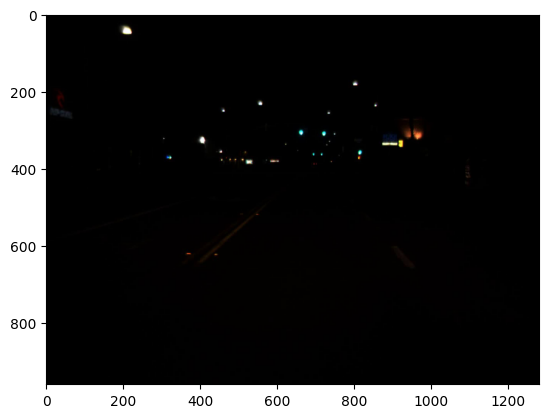

In [39]:
import cv2

nt_image= cv2.imread(found_path[0])
nt_image = cv2.cvtColor(nt_image, cv2.COLOR_BGR2RGB)
imshow_(nt_image)

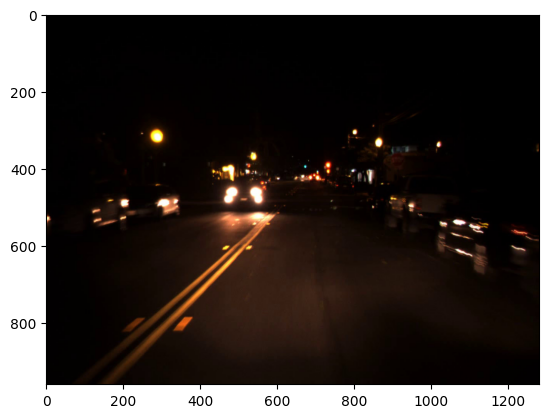

In [40]:
ns_image= cv2.imread(found_path[1])
ns_image = cv2.cvtColor(ns_image, cv2.COLOR_BGR2RGB)
imshow_(ns_image)

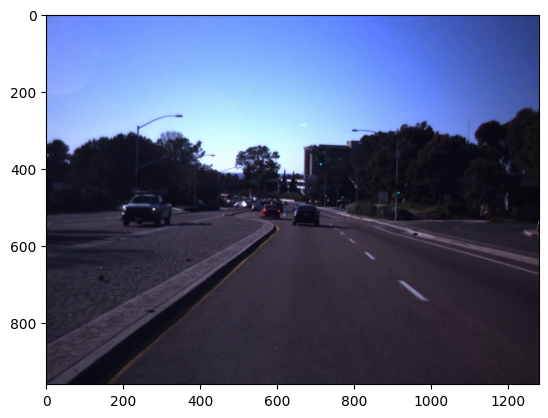

In [41]:
dt_image= cv2.imread(found_path[4])
dt_image = cv2.cvtColor(dt_image, cv2.COLOR_BGR2RGB)
imshow_(dt_image)

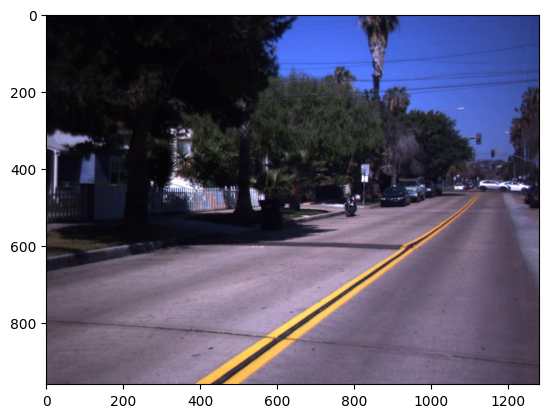

In [42]:
ds_image= cv2.imread(found_path[3])
ds_image = cv2.cvtColor(ds_image, cv2.COLOR_BGR2RGB)
imshow_(ds_image)

In [ ]:
from torch.utils.data import Dataset, DataLoader


class LisaTrafficDataset(Dataset):
    def __init__(self, annotations, root_dir, transform=None):
        self.annotations = annotations
        self.root_dir = root_dir
        self.transform = transform
        self.len = len(self.annotations)
        self.image_lookup = {}
        for path in Path(root_dir).rglob("*.jpg"):
            self.image_lookup[path.name] = str(path)
        print(f"found {len(self.image_lookup)} images")

    def __getitem__(self, idx):
        row = self.annotations.iloc[idx]

        raw_file = row["Filename"].replace("\\", "/").split("/")[-1]
        image_path = self.image_lookup.get(raw_file)
        if image_path is None:
            raise FileNotFoundError(
                f"Image '{raw_file}' was not found in root_dir '{self.root_dir}'"
            )
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        box = [
            float(row["Upper left corner X"]),
            float(row["Upper left corner Y"]),
            float(row["Lower right corner X"]),
            float(row["Lower right corner Y"]),
        ]

        target = {
            "boxes": torch.tensor([box], dtype=torch.float32),
            "labels": torch.tensor(
                [self.label_to_id(row["Annotation tag"])], dtype=torch.int64
            ),
        }

        if self.transform:
            image = self.transform(image)
        return image, target

    def __len__(self):
        return self.len

    def label_to_id(self, label_str):
        mapping = {"go": 1, "stop": 2, "warning": 3, "goForward": 1}
        return mapping.get(label_str, 0)

In [45]:
transform = transforms.Compose([
    transforms.ToTensor(),
    
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [50]:
nt_dataset= LisaTrafficDataset(annotations1, dataset_path,transform)
dt_dataset= LisaTrafficDataset(annotations2, dataset_path,transform)
ns_dataset= LisaTrafficDataset(annotations3, dataset_path,transform)
ds2_dataset= LisaTrafficDataset(annotations4, dataset_path,transform)

found 43016 images
found 43016 images
found 43016 images
found 43016 images


In [51]:
image_nt, target_nt= nt_dataset[1]
image_dt, target_dt= dt_dataset[1]
image_ns, target_ns= ns_dataset[1]
image_ds2, target_ds2= ds2_dataset[1]

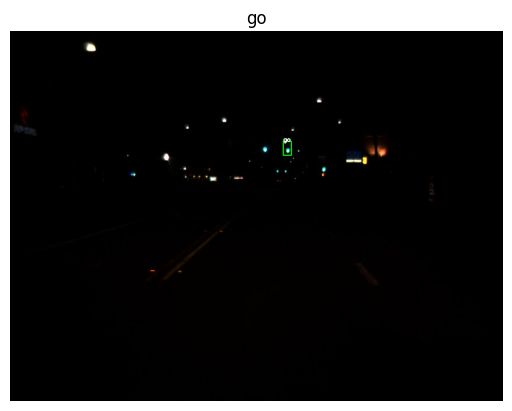

In [52]:
reveal_dataset(target_nt,image_nt,2,2)

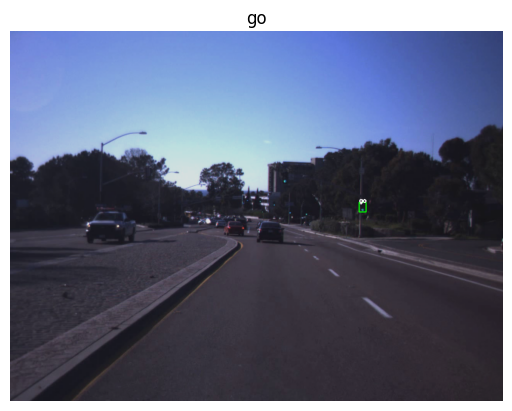

In [53]:
reveal_dataset(target_dt,image_dt,2,2)

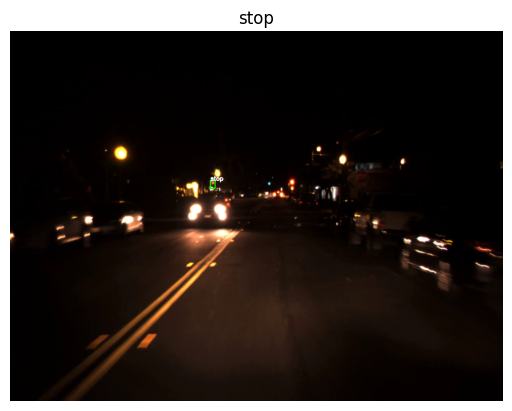

In [54]:
reveal_dataset(target_ns,image_ns,2,2)

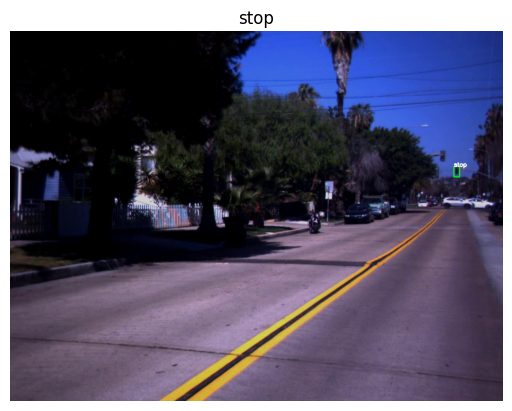

In [55]:
reveal_dataset(target_ds2,image_ds2,2,2)

In [129]:
path = list(Path(dataset_path).rglob(annotate['Filename'].iloc[1].split('/')[-1]))
print(path[0])
print(Path(annotate['clip'].iloc[1]).name)

/kaggle/input/datasets/mbornoe/lisa-traffic-light-dataset/nightSequence1/nightSequence1/frames/nightSequence1--00000.jpg
nightSequence1


In [131]:
path_map = {(p.parent.parent.name,  p.name): str(p) for p in Path(dataset_path).rglob("*") if p.is_file()}
missing = 0

for _, row in annotate.iterrows():
    clip = Path(row["clip"]).name
    file_name = Path(row["Filename"]).name

    if (clip, file_name) not in path_map:
        missing += 1

print("Missing:", missing)

Missing: 0


In [126]:
print("Annotation clips:")
print(annotate["clip"].unique()[:30])

print("\nImage path parent.parent names:")
print(
    sorted({
        p.parent.parent.name
        for p in Path(dataset_path).rglob("*.jpg")
    })[:30]
)

Annotation clips:
['nightSequence1' 'daySequence1' 'daySequence2' 'nightSequence2'
 'nightTrain/nightClip1' 'nightTrain/nightClip4' 'nightTrain/nightClip3'
 'nightTrain/nightClip2' 'nightTrain/nightClip5' 'dayTrain/dayClip13'
 'dayTrain/dayClip11' 'dayTrain/dayClip7' 'dayTrain/dayClip4'
 'dayTrain/dayClip1' 'dayTrain/dayClip2' 'dayTrain/dayClip12'
 'dayTrain/dayClip5' 'dayTrain/dayClip8' 'dayTrain/dayClip9'
 'dayTrain/dayClip6' 'dayTrain/dayClip10' 'dayTrain/dayClip3']

Image path parent.parent names:
['dayClip1', 'dayClip10', 'dayClip11', 'dayClip12', 'dayClip13', 'dayClip2', 'dayClip3', 'dayClip4', 'dayClip5', 'dayClip6', 'dayClip7', 'dayClip8', 'dayClip9', 'daySequence1', 'daySequence2', 'nightClip1', 'nightClip2', 'nightClip3', 'nightClip4', 'nightClip5', 'nightSequence1', 'nightSequence2', 'sample-dayClip6', 'sample-nightClip1']


In [95]:
from collections import Counter

names = [p.name for p in Path(dataset_path).rglob("*.jpg")]

duplicates = {
    name: count
    for name, count in Counter(names).items()
    if count > 1
}

print(len(duplicates))

1059


In [ ]:
import shutil

output_text_dir = "labels"
if os.path.exists(output_text_dir):
    shutil.rmtree(output_text_dir)
os.makedirs(output_text_dir, exist_ok=True)
dim_cache = {}
path_map = {
    (p.parent.parent.name, p.name): str(p)
    for p in Path(dataset_path).rglob("*")
    if p.is_file()
}

missing = 0
invalid = 0
written = 0
for idx, split in annotate.iterrows():
    clip = Path(split["clip"]).name
    file_name = Path(split["Filename"]).name
    image_path = path_map.get((clip, file_name))
    if image_path is None:
        missing += 1
        continue
    if image_path in dim_cache:
        img_height, img_width = dim_cache[image_path]
    else:
        image = cv2.imread(image_path)
        if image is None:
            missing += 1
            continue
        img_height, img_width, _ = image.shape
        dim_cache[image_path] = (img_height, img_width)
    x_min = split["Upper left corner X"]
    y_min = split["Upper left corner Y"]
    x_max = split["Lower right corner X"]
    y_max = split["Lower right corner Y"]
    class_id = split["class_id"]

    if x_max <= x_min or y_max <= y_min:
        invalid += 1
        continue

    if not (
        0 <= x_min < img_width
        and 0 < x_max <= img_width
        and 0 <= y_min < img_height
        and 0 < y_max <= img_height
    ):
        invalid += 1
        continue

    x_center = ((x_min + x_max) / 2.00) / img_width
    y_center = ((y_min + y_max) / 2.00) / img_height
    width = (x_max - x_min) / img_width
    height = (y_max - y_min) / img_height

    parent_name = Path(image_path).parent.parent.name
    base_name = Path(image_path).stem
    text_file = os.path.join(output_text_dir, f"{parent_name}_{base_name}.txt")

    with open(text_file, "a") as f:
        f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f} \n")
        written += 1

print("\n Missing: ", missing)
print("\n Invalid: ", invalid)
print("\n Written: ", written)


 Missing:  0

 Invalid:  0

 Written:  109475


In [136]:
print("Annotation rows:", len(annotate))
print("Label files:", len(os.listdir(output_text_dir)))

Annotation rows: 109475
Label files: 36265


In [138]:
label_files = list(Path(output_text_dir).glob("*.txt"))

for path in label_files[:5]:
    print(f"\n--- {path.name} ---")
    print(path.read_text())


--- daySequence2_daySequence2--02696.txt ---
2 0.695312 0.412500 0.009375 0.020833 
2 0.301953 0.278125 0.021094 0.041667 


--- daySequence2_daySequence2--06450.txt ---
0 0.652344 0.269792 0.023438 0.041667 
0 0.843359 0.354167 0.021094 0.037500 
2 0.522656 0.272396 0.023438 0.046875 


--- nightClip2_nightClip2--01475.txt ---
0 0.550781 0.398438 0.007812 0.021875 


--- dayClip5_dayClip5--01226.txt ---
0 0.737109 0.185938 0.039844 0.088542 
0 0.901563 0.235417 0.028125 0.079167 
0 0.583594 0.176563 0.046875 0.088542 


--- dayClip9_dayClip9--00575.txt ---
2 0.812891 0.197917 0.025781 0.072917 
0 0.625781 0.199479 0.032813 0.069792 

